In [5]:

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv('HousingData.csv')

In [34]:
X=df.drop('MEDV',axis=1)
y=df['MEDV'].values.reshape(-1,1)

In [35]:
df.isnull().sum()


,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [37]:
df = df.dropna()
X=df.drop('MEDV',axis=1)
y=df['MEDV'].values.reshape(-1,1)


<Axes: >

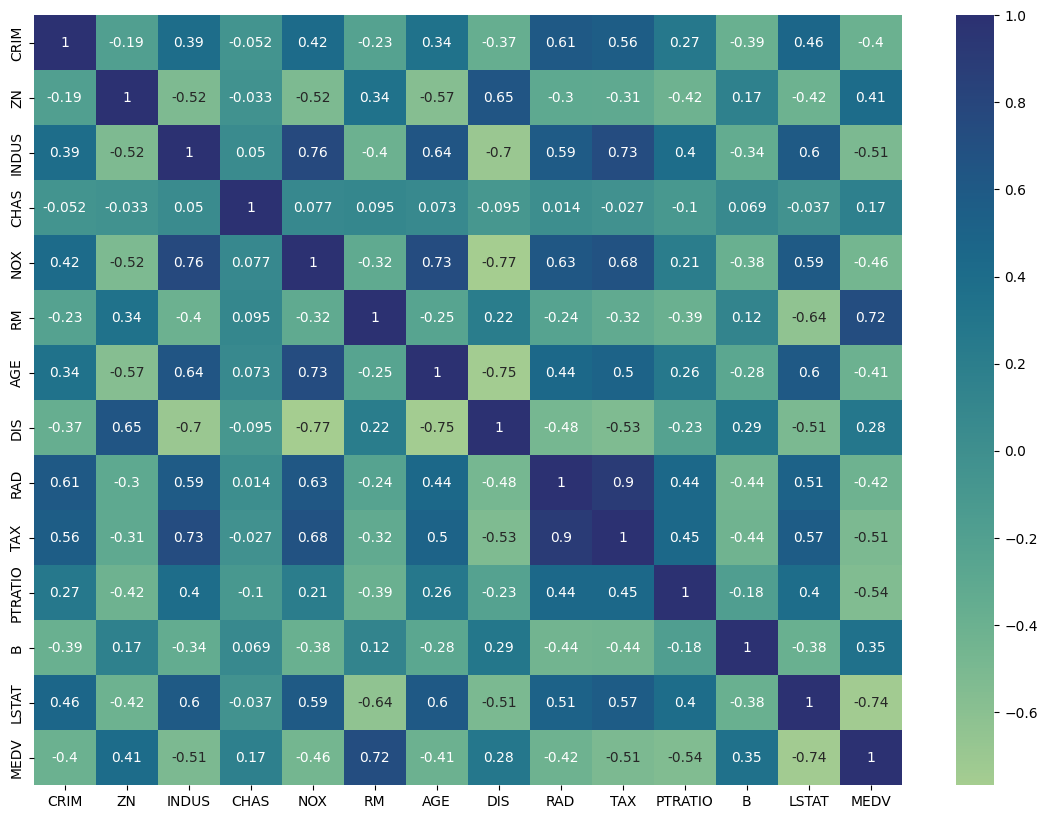

In [38]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='crest', annot=True)

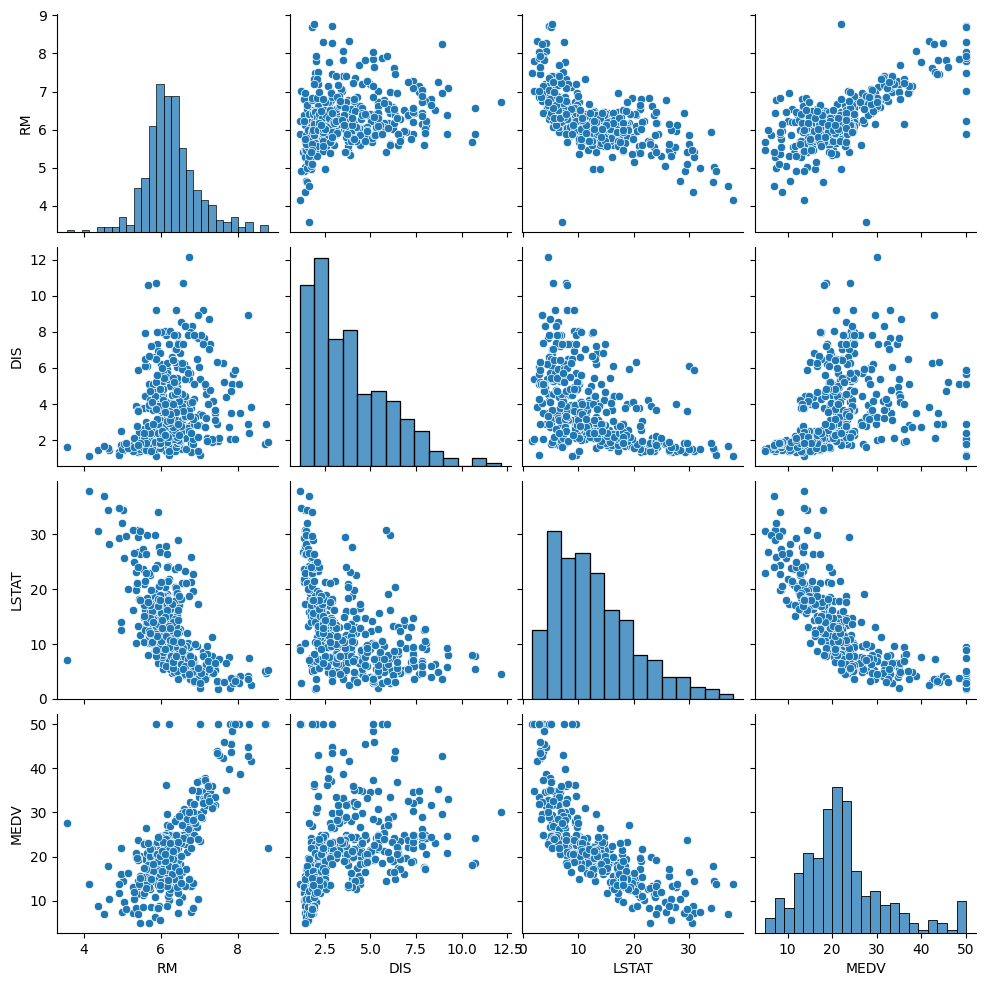

In [39]:
sns.pairplot(df[['RM', 'DIS', 'LSTAT', 'MEDV']])


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [41]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [50]:
model=Sequential()


In [51]:
model.add(Dense(128,input_shape=(1,),activation='relu',name='input'))
model.add(Dense(64,activation='relu',name='layer_1'))
model.add(Dense(1,name='output'))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(units=64, activation='relu', input_shape=(13,)))  # Update input_shape to (13,)
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1, activation='linear'))

model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, batch_size=32)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.9277 - val_loss: 0.5550
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6814 - val_loss: 0.4512
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4106 - val_loss: 0.4077
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4134 - val_loss: 0.3674
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2737 - val_loss: 0.3208
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2891 - val_loss: 0.2859
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2726 - val_loss: 0.2598
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1611 - val_loss: 0.2435
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1577 - val_loss: 0.2269
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1782 - val_loss: 0.2126
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1384 - val_loss: 0.2038
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1094 - val_lo

In [56]:
# Compile the model with loss and mae as metrics
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Evaluate the model
output = model.evaluate(X_test, y_test)

# Print the loss and MAE
print(f"Test Loss: {output[0]:.4f}, Test MAE: {output[1]:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2525 - mae: 0.2654 
Test Loss: 0.2285, Test MAE: 0.2621


In [57]:
print(f"Mean Squared Error: {output[0]}"
      ,f"Mean Absolute Error: {output[1]}",sep="\n")


Mean Squared Error: 0.22847096621990204
Mean Absolute Error: 0.26212069392204285


In [58]:
y_pred=model.predict(X_test)
# y_pred


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


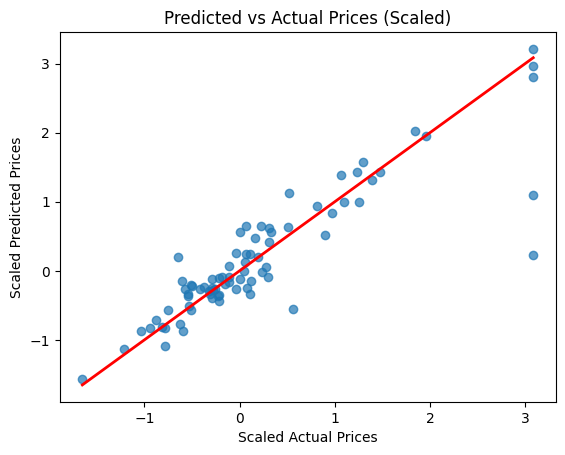

In [59]:
import matplotlib.pyplot as plt

# Plot Predicted vs Actual values in scaled form
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)  # Line for perfect prediction
plt.xlabel("Scaled Actual Prices")
plt.ylabel("Scaled Predicted Prices")
plt.title("Predicted vs Actual Prices (Scaled)")
plt.show()